In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT=Path.cwd().parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

# Load cleaned data
df = pd.read_csv(DATA_PROCESSED / 'ads_cleaned.csv')

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(df.columns.tolist())


Loaded: 300,000 rows x 25 cols
['campaign_id', 'target_audience', 'campaign_goal', 'duration', 'channel_used', 'conversion_rate', 'acquisition_cost', 'roi', 'location', 'language', 'clicks', 'impressions', 'engagement_score', 'customer_segment', 'date', 'company', 'month', 'dayofweek', 'ctr', 'day_of_week', 'cpc', 'cpm', 'estimated_revenue', 'profit', 'conversions']


channel_used  campaigns  avg_ctr  avg_cpc  avg_cpm  avg_roi  avg_conv_rate  total_spend  total_revenue
    Facebook      75164  32.1359   0.3878 124.1850   3.9869         0.0799 582146894.91   2.904407e+09
   Instagram      75101  32.1317   0.3875 124.0935   4.0088         0.0798 580249312.51   2.906949e+09
   Pinterest      75082  29.2396   0.6599 192.3186   0.7164         0.0800 583367525.78   1.001381e+09
     Twitter      74653  32.1585   0.3876 124.2137   4.0022         0.0804 580361505.74   2.899829e+09


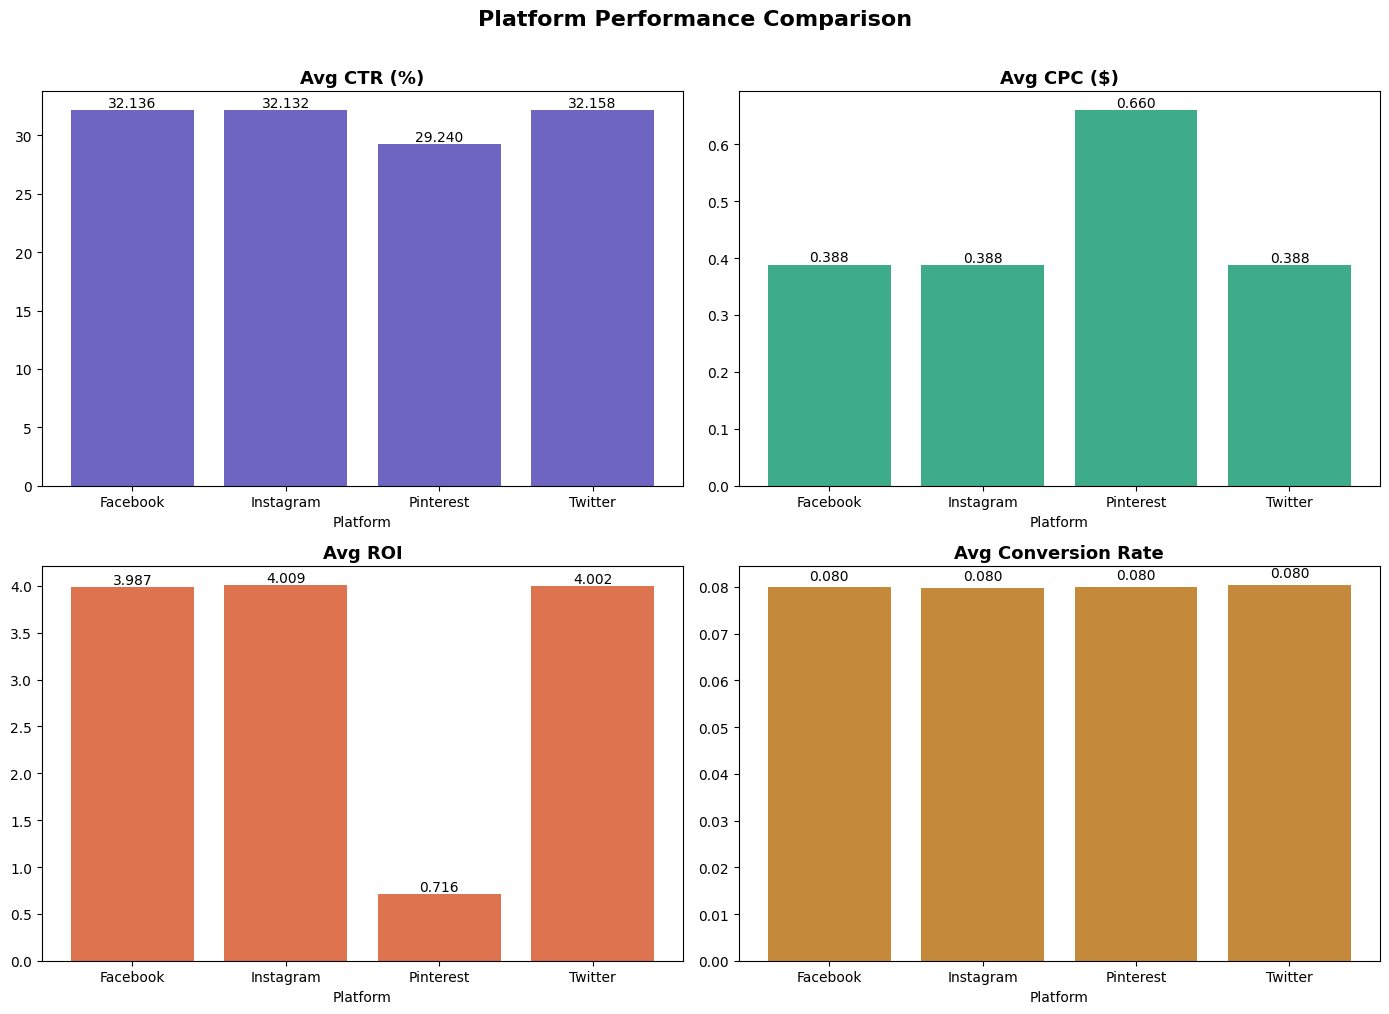

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

platform_metrics= df.groupby('channel_used').agg(
    campaigns=('campaign_id','count'),
    avg_ctr=('ctr','mean'),
    avg_cpc=('cpc','mean'),
    avg_cpm=('cpm','mean'),
    avg_roi=('roi','mean'),
    avg_conv_rate=('conversion_rate','mean'),
    total_spend=('acquisition_cost','sum'),
    total_revenue=('estimated_revenue','sum'),
).round(4).reset_index()

print(platform_metrics.to_string(index=False))

#Bar chart-CTR by platform
fig,axes=plt.subplots(2,2,figsize=(14,10))
metrics=['avg_ctr','avg_cpc','avg_roi','avg_conv_rate']
titles=['Avg CTR (%)','Avg CPC ($)','Avg ROI','Avg Conversion Rate']
colors=['#534AB7', '#1D9E75', '#D85A30', '#BA7517']

for ax,metric,title,color in zip(axes.flatten(),metrics, titles,colors):
    bars = ax.bar(platform_metrics['channel_used'],
                  platform_metrics[metric], color=color, alpha=0.85)
    ax.set_title(title,fontsize=13,fontweight='bold')
    ax.set_xlabel('Platform')
    #Add value labels on bars
    for bar,val in zip(bars,platform_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() +0.001,
        f'{val:.3f}',ha='center',va='bottom',fontsize=10)

plt.suptitle('Platform Performance Comparison',fontsize=16,fontweight='bold',y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/platform_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

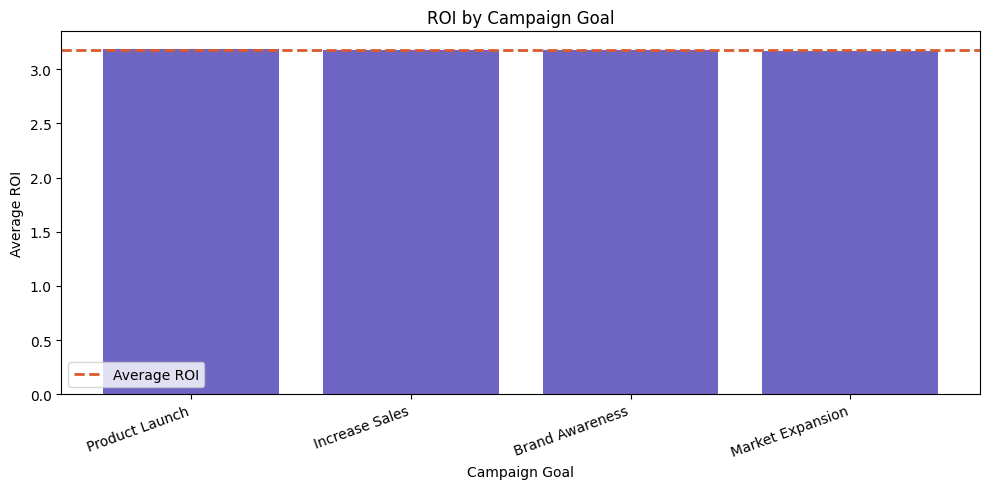

In [5]:
goal_metrics=df.groupby('campaign_goal').agg(
    avg_roi=('roi','mean'),
    avg_conv_rate=('conversion_rate','mean'),
    total_spend=('acquisition_cost','sum'),
    campaigns=('campaign_id','count')
).round(4).sort_values('avg_roi',ascending=False).reset_index()

plt.figure(figsize=(10,5))
bars=plt.bar(goal_metrics['campaign_goal'], goal_metrics['avg_roi'], color='#534AB7', alpha=0.85)
plt.axhline(y=goal_metrics['avg_roi'].mean(), color='#D85A30', linestyle='--', linewidth=2,label='Average ROI')
plt.xlabel('Campaign Goal')
plt.ylabel('Average ROI')
plt.title('ROI by Campaign Goal')
plt.xticks(rotation=20, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/roi_by_goal.png', dpi=150, bbox_inches='tight')
plt.show()


Top performing segments:
customer_segment  avg_roi  avg_conv_rate  avg_ctr  total_spend  campaigns
      Technology   3.1924         0.0801  31.4309 464512217.83      59840
          Health   3.1860         0.0799  31.4062 464949446.68      60086
         Fashion   3.1779         0.0801  31.4276 465289107.65      59940
            Home   3.1695         0.0800  31.4017 466279540.61      60077
            Food   3.1627         0.0799  31.4117 465094926.17      60057


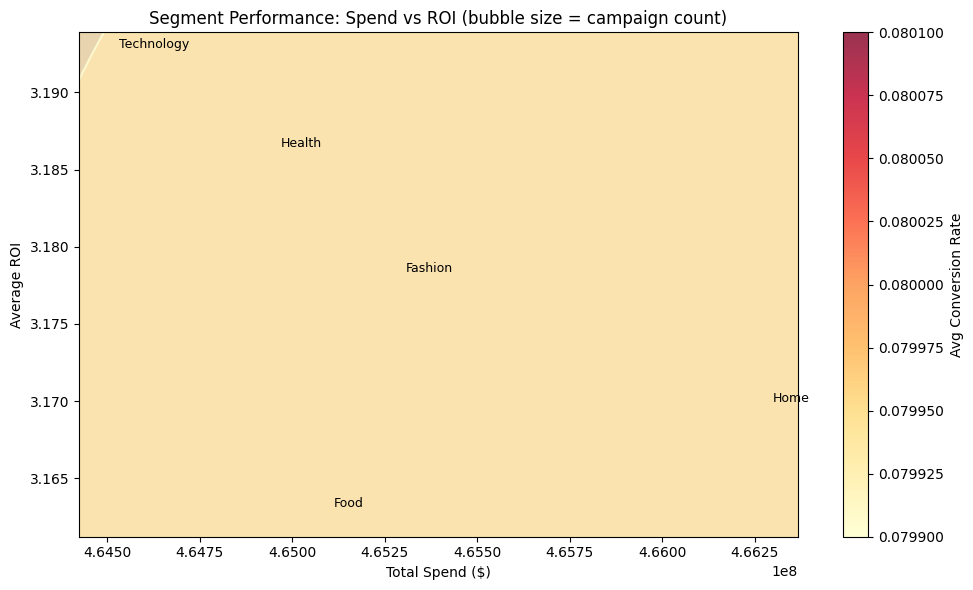

In [17]:
segment_metrics = df.groupby('customer_segment').agg(
    avg_roi       = ('roi', 'mean'),
    avg_conv_rate = ('conversion_rate', 'mean'),
    avg_ctr       = ('ctr', 'mean'),
    total_spend   = ('acquisition_cost', 'sum'),
    campaigns     = ('campaign_id', 'count')
).round(4).sort_values('avg_roi', ascending=False).reset_index()

print('Top performing segments:')
print(segment_metrics.head().to_string(index=False))

# Bubble chart — spend vs ROI, sized by campaigns
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    segment_metrics['total_spend'],
    segment_metrics['avg_roi'],
    s=segment_metrics['campaigns'] * 20,
    c=segment_metrics['avg_conv_rate'],
    cmap='YlOrRd', alpha=0.8, edgecolors='white', linewidth=1.5
)
for _, row in segment_metrics.iterrows():
    plt.annotate(row['customer_segment'],
                 (row['total_spend'], row['avg_roi']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
plt.colorbar(scatter, label='Avg Conversion Rate')
plt.xlabel('Total Spend ($)')
plt.ylabel('Average ROI')
plt.title('Segment Performance: Spend vs ROI (bubble size = campaign count)')
plt.tight_layout()
plt.savefig('../reports/figures/segment_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
